In [2]:
import librosa
print("Librosa installed successfully")

Librosa installed successfully


In [3]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

print("Everything working!")

Everything working!


In [4]:
audio, sr = librosa.load("../data/jakob_welik-please-hold-me-the-ache-of-remembering-413875.mp3")

In [5]:
print("Sample Rate:", sr)
print("Audio Shape:", audio.shape)

print(audio[:10])

Sample Rate: 22050
Audio Shape: (5012054,)
[ 6.2235724e-11 -3.9698848e-11  1.4052053e-11 -1.9760213e-12
  3.0663413e-11 -6.7664443e-11 -4.9899723e-11 -6.3987843e-11
  8.3779775e-11  1.3677207e-10]


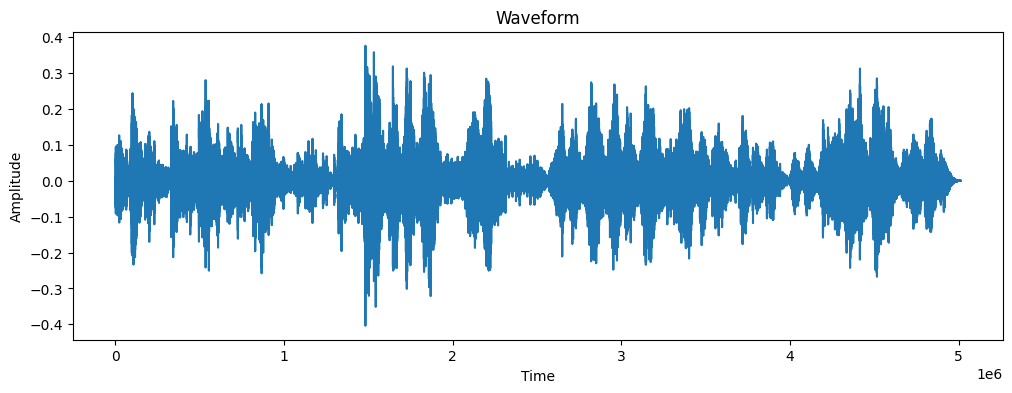

In [6]:
plt.figure(figsize=(12,4))

plt.plot(audio)

plt.title("Waveform")
plt.xlabel("Time")
plt.ylabel("Amplitude")

plt.show()

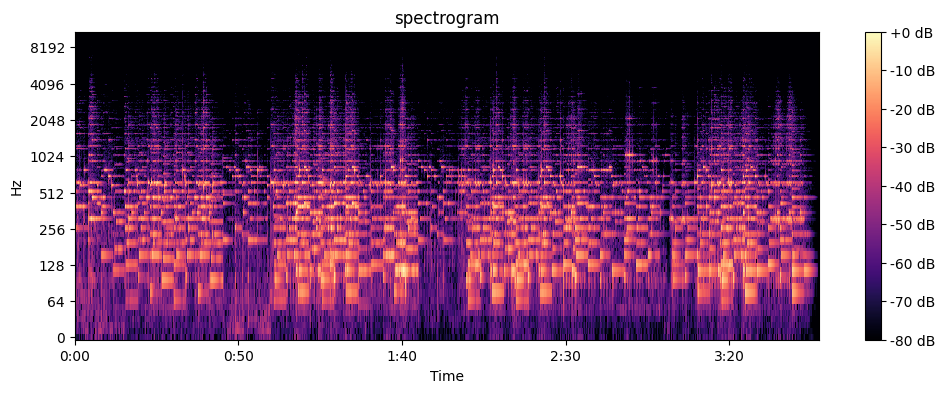

In [7]:
D=librosa.amplitude_to_db(
    np.abs(librosa.stft(audio)),
    ref=np.max
)
plt.figure(figsize=(12,4))
librosa.display.specshow(
    D,
    sr=sr,
    x_axis='time',
    y_axis='log'
)
plt.colorbar(format='%+2.0f dB')
plt.title("spectrogram")
plt.show()

In [8]:
mfccs=librosa.feature.mfcc(
    y=audio,
    sr=sr,
    n_mfcc=13
)
print(mfccs.shape)

(13, 9790)


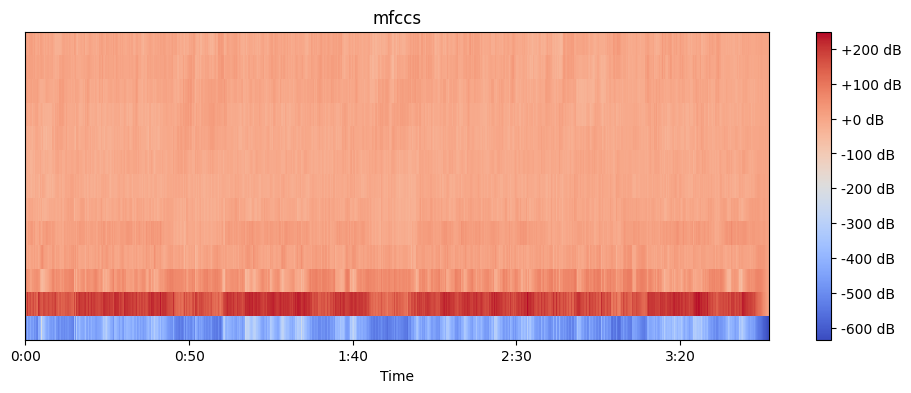

In [9]:
plt.figure(figsize=(12,4))
librosa.display.specshow(
    mfccs,
    x_axis='time'
)
plt.colorbar(format='%+2.0f dB')
plt.title("mfccs")
plt.show()

In [10]:
import os 
import pandas as pd

In [11]:
def extract_features(file_path):
    audio,sr=librosa.load(file_path)
    mfccs=librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=13
    )
    mfcc_mean=np.mean(mfccs,axis=1)
    tempo,_=librosa.beat.beat_track(
        y=audio,
        sr=sr, 
    )
    tempo=tempo.item()
    spectral_centroid=np.mean(
        librosa.feature.spectral_centroid(
            y=audio,
            sr=sr
        )
    )
    zero_crossing_rate=np.mean(
        librosa.feature.zero_crossing_rate(audio)
    )
    rms = np.mean(
    librosa.feature.rms(y=audio)
   )
    chroma = np.mean(
    librosa.feature.chroma_stft(
        y=audio,
        sr=sr
    ),
    axis=1
    )
    spectral_bandwidth = np.mean(
    librosa.feature.spectral_bandwidth(
        y=audio,
        sr=sr
    )
    )
    features={
        "tempo":tempo,
        "spectral_centroid":spectral_centroid,
        "zero_crossing_rate":zero_crossing_rate,
        "rms":rms,
        "spectral_bandwidth":spectral_bandwidth
    }
    for i in range(12):
       features[f"chroma_{i+1}"] = chroma[i]

    for i in range(13):
        features[f"mfcc_{i+1}"]=mfcc_mean[i]

    return features

In [12]:
data=[]
folder="../data"
for file in os.listdir(folder):
    if file.endswith(".mp3"):
        path=os.path.join(folder,file)
        features = extract_features(path)
        features["filename"]=file
        data.append(features)

In [13]:
df=pd.DataFrame(data)
df.head()

,tempo,spectral_centroid,zero_crossing_rate,rms,spectral_bandwidth,chroma_1,chroma_2,chroma_3,chroma_4,chroma_5,...,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13,filename
0,135.999178,591.456809,0.042005,0.032326,798.928483,0.205255,0.106038,0.273929,0.478606,0.176355,...,11.569395,-4.706891,-10.377657,-7.404225,-7.742661,-7.021876,-2.411005,-0.603114,-3.874529,jakob_welik-please-hold-me-the-ache-of-remembe...
1,143.554688,2779.199249,0.126445,0.159069,2595.783285,0.496474,0.314718,0.292539,0.413300,0.490022,...,-6.853355,3.333641,0.262704,7.908114,7.349022,11.948710,5.062164,-2.320438,-7.832904,nickpanekaiassets-heavy-drag-mid-tempo-nu-meta...
2,143.554688,2779.199249,0.126445,0.159069,2595.783285,0.496474,0.314718,0.292539,0.413300,0.490022,...,-6.853355,3.333641,0.262704,7.908114,7.349022,11.948710,5.062164,-2.320438,-7.832904,nickpanekaiassets-heavy-drag-mid-tempo-nu-meta...
3,69.837416,616.969523,0.044277,0.035280,843.419199,0.381046,0.141595,0.154631,0.131279,0.332838,...,-3.055832,-2.430264,-4.432064,-6.057765,-6.599862,-10.219099,-12.672074,-9.352031,-5.439627,piano_music-calm-me-down-142605.mp3
4,123.046875,2473.785507,0.093725,0.240755,2609.549834,0.495287,0.460287,0.351377,0.326198,0.329878,...,7.986912,14.487442,2.873442,6.535125,-3.182473,5.930130,-2.281124,1.519786,-4.788159,playhousesound-play-house-about-me-official-au...


In [14]:
from sklearn.metrics.pairwise import cosine_similarity

In [15]:
feature_columns=df.columns.drop("filename")
X=df[feature_columns]


In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [17]:
similarity = cosine_similarity(X)

In [18]:
similarity_old = cosine_similarity(X)

similarity_new = cosine_similarity(X_scaled)

In [19]:
def recommend(song_name):
    index=df[df["filename"]==song_name].index[0]
    similarity_scores=list(
        enumerate(similarity[index])
    )
    similarity_scores=sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )
    for i in similarity_scores[1:4]:
       print(
        df.iloc[i[0]]["filename"],
        "Similarity:",
        round(i[1],3)
)

In [20]:
recommend("piano_music-calm-me-down-142605.mp3")

jakob_welik-please-hold-me-the-ache-of-remembering-413875.mp3 Similarity: 0.998
playhousesound-play-house-about-me-official-audio-361620.mp3 Similarity: 0.909
nickpanekaiassets-heavy-drag-mid-tempo-nu-metal-instrumental-379674 (1).mp3 Similarity: 0.899


In [21]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
X_pca=pca.fit_transform(X_scaled)

In [22]:
X_pca.shape

(5, 2)

In [23]:
print(X_pca)

[[-5.62516218  2.93757545]
 [ 4.45800444 -0.68816612]
 [ 4.45800444 -0.68816612]
 [-5.77320336 -3.21426966]
 [ 2.48235666  1.65302644]]


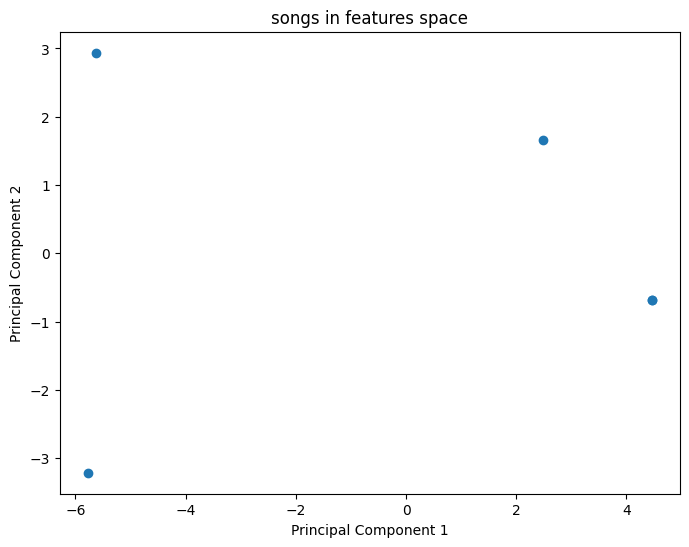

In [24]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1]
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("songs in features space")
plt.show()

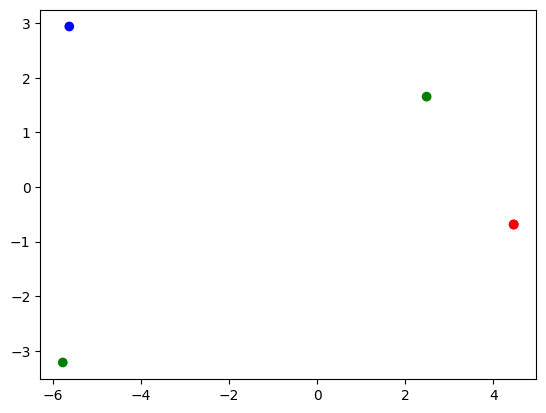

In [25]:
colors = [
    "blue",
    "blue",
    "red",
    "green",
    "green"
]

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=colors
)

In [26]:
import os 
import librosa
import numpy as np
import pandas as pd
def extract_features(file_path):
    audio,sr=librosa.load(file_path)
    mfccs=librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=13
    )
    mfcc_mean=np.mean(mfccs,axis=1)
    tempo,_=librosa.beat.beat_track(
        y=audio,
        sr=sr, 
    )
    tempo = float(np.asarray(tempo).squeeze())
    spectral_centroid=np.mean(
        librosa.feature.spectral_centroid(
            y=audio,
            sr=sr
        )
    )
    zero_crossing_rate=np.mean(
        librosa.feature.zero_crossing_rate(audio)
    )
    rms = np.mean(
    librosa.feature.rms(y=audio)
   )
    chroma = np.mean(
    librosa.feature.chroma_stft(
        y=audio,
        sr=sr
    ),
    axis=1
    )
    spectral_bandwidth = np.mean(
    librosa.feature.spectral_bandwidth(
        y=audio,
        sr=sr
    )
    )
    features={
        "tempo":tempo,
        "spectral_centroid":spectral_centroid,
        "zero_crossing_rate":zero_crossing_rate,
        "rms":rms,
        "spectral_bandwidth":spectral_bandwidth
    }
    for i in range(12):
       features[f"chroma_{i+1}"] = chroma[i]

    for i in range(13):
        features[f"mfcc_{i+1}"]=mfcc_mean[i]

    return features



In [27]:
data = []

for mood in os.listdir("../data"):

    mood_folder = os.path.join("../data", mood)

    if os.path.isdir(mood_folder):

        files = [f for f in os.listdir(mood_folder)
                 if f.endswith(".wav")]

        files = files[:100]

        for file in files:

            path = os.path.join(
                mood_folder,
                file
            )

            features = extract_features(path)

            features["filename"] = file
            features["mood"] = mood

            data.append(features)

df=pd.DataFrame(data)
print(df.shape)
df.head()

(500, 32)


,tempo,spectral_centroid,zero_crossing_rate,rms,spectral_bandwidth,chroma_1,chroma_2,chroma_3,chroma_4,chroma_5,...,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13,filename,mood
0,143.554688,1412.773827,0.075562,0.267882,1516.705232,0.710648,0.551436,0.538069,0.569491,0.584511,...,11.150761,9.774574,7.931699,2.282266,7.696911,5.632815,6.667282,3.537104,6761.wav,aggressive
1,143.554688,1148.662470,0.062288,0.258414,1263.426648,0.710561,0.544693,0.538965,0.602402,0.592129,...,12.188366,10.537190,6.218566,2.817331,7.377258,5.987830,6.832986,4.034082,6762.wav,aggressive
2,143.554688,1067.859161,0.054088,0.258337,1234.461987,0.723735,0.559817,0.550333,0.635521,0.601308,...,12.125932,10.640311,4.941592,2.607408,7.383556,6.056402,7.169575,4.789241,6763.wav,aggressive
3,143.554688,1128.592994,0.049931,0.256904,1369.767340,0.719626,0.548857,0.569624,0.638061,0.574309,...,13.776545,7.394137,5.054174,1.308494,7.382347,5.516985,7.764492,5.118814,6764.wav,aggressive
4,143.554688,1077.720034,0.047106,0.249672,1345.899606,0.732564,0.548935,0.583353,0.642553,0.582174,...,12.811049,7.618975,4.301260,2.015421,6.613831,5.809652,7.665783,6.033866,6765.wav,aggressive


In [28]:
df["mood"].value_counts()

mood
aggressive    100
dramatic      100
happy         100
romantic      100
sad           100
Name: count, dtype: int64

In [29]:
df.to_csv(
    "../data/music_features_dataset.csv",
    index=  False
)

In [30]:
X=df.drop(
    columns=["filename","mood"]

)
y=df["mood"]


In [31]:
print(X.shape)
print(y.shape)

(500, 30)
(500,)


In [32]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(X_train.shape)
print(X_test.shape)

(400, 30)
(100, 30)


In [33]:
mood="happy"
mood_folder=os.path.join("../data",mood)
file=os.listdir(mood_folder)[0]
path=os.path.join(mood_folder,file)
features=extract_features(path)
print(features)

{'tempo': 95.703125, 'spectral_centroid': np.float64(2599.8904007896267), 'zero_crossing_rate': np.float64(0.11716715494791667), 'rms': np.float32(0.06324433), 'spectral_bandwidth': np.float64(2544.4234596171596), 'chroma_1': np.float32(0.48488042), 'chroma_2': np.float32(0.38404548), 'chroma_3': np.float32(0.34214252), 'chroma_4': np.float32(0.36274597), 'chroma_5': np.float32(0.49069074), 'chroma_6': np.float32(0.6020127), 'chroma_7': np.float32(0.36334985), 'chroma_8': np.float32(0.33118057), 'chroma_9': np.float32(0.43819192), 'chroma_10': np.float32(0.6890267), 'chroma_11': np.float32(0.6741589), 'chroma_12': np.float32(0.54483825), 'mfcc_1': np.float32(-240.15358), 'mfcc_2': np.float32(66.23796), 'mfcc_3': np.float32(7.9315796), 'mfcc_4': np.float32(32.498413), 'mfcc_5': np.float32(3.235002), 'mfcc_6': np.float32(13.906573), 'mfcc_7': np.float32(5.2989106), 'mfcc_8': np.float32(2.0821218), 'mfcc_9': np.float32(0.7720948), 'mfcc_10': np.float32(3.3394423), 'mfcc_11': np.float32(-4

In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import(
    accuracy_score,
    classification_report,
    confusion_matrix
)
model=RandomForestClassifier(
    n_estimators=50,
    random_state=42
)
model.fit(
    X_train,
    y_train
)
predictions=model.predict(
    X_test
)
accuracy=accuracy_score(
    y_test,
    predictions
)
print("Accuracy:",accuracy)
print(
    classification_report(
        y_test,
        predictions
    )
)
cm=confusion_matrix(
    y_test,
    predictions
)
print(cm)


Accuracy: 0.99
              precision    recall  f1-score   support

  aggressive       0.95      1.00      0.98        20
    dramatic       1.00      1.00      1.00        20
       happy       1.00      0.95      0.97        20
    romantic       1.00      1.00      1.00        20
         sad       1.00      1.00      1.00        20

    accuracy                           0.99       100
   macro avg       0.99      0.99      0.99       100
weighted avg       0.99      0.99      0.99       100

[[20  0  0  0  0]
 [ 0 20  0  0  0]
 [ 1  0 19  0  0]
 [ 0  0  0 20  0]
 [ 0  0  0  0 20]]


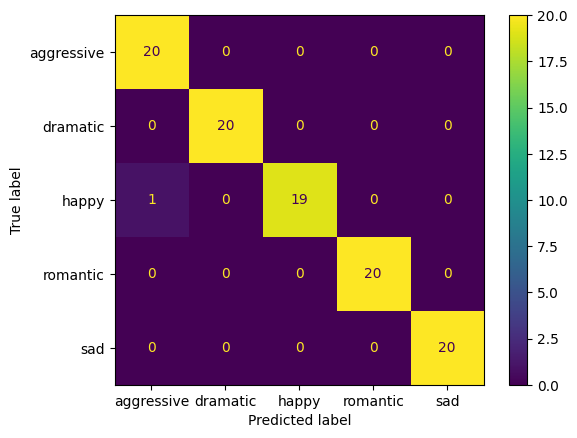

In [35]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions
)
plt.show()

In [36]:
import pandas as pd
importance=pd.DataFrame(
    {
        "feature": X.columns,
        "importance": model.feature_importances_
    }
)
importance=importance.sort_values(
    "importance",
    ascending=False
)
print(importance.head(10))


               feature  importance
1    spectral_centroid    0.072843
19              mfcc_3    0.066527
28             mfcc_12    0.050095
27             mfcc_11    0.050015
13            chroma_9    0.049002
3                  rms    0.047300
17              mfcc_1    0.045428
4   spectral_bandwidth    0.044013
8             chroma_4    0.043071
14           chroma_10    0.040172


In [37]:
import joblib
joblib.dump(
    model,
    "music_mood_model.pkl"
)

['music_mood_model.pkl']

In [38]:
print("Accuracy:",accuracy)

Accuracy: 0.99


In [39]:
joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

['../models/scaler.pkl']

In [40]:
import joblib
import os 
import librosa
import numpy as np
import pandas as pd
model=joblib.load(
    "music_mood_model.pkl"
)
scaler=joblib.load(
    "scaler.pkl"
)
def extract_features(file_path):
    audio,sr=librosa.load(file_path)
    mfccs=librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=13
    )
    mfcc_mean=np.mean(mfccs,axis=1)
    tempo,_=librosa.beat.beat_track(
        y=audio,
        sr=sr, 
    )
    tempo = float(np.asarray(tempo).squeeze())
    spectral_centroid=np.mean(
        librosa.feature.spectral_centroid(
            y=audio,
            sr=sr
        )
    )
    zero_crossing_rate=np.mean(
        librosa.feature.zero_crossing_rate(audio)
    )
    rms = np.mean(
    librosa.feature.rms(y=audio)
   )
    chroma = np.mean(
    librosa.feature.chroma_stft(
        y=audio,
        sr=sr
    ),
    axis=1
    )
    spectral_bandwidth = np.mean(
    librosa.feature.spectral_bandwidth(
        y=audio,
        sr=sr
    )
    )
    features={
        "tempo":tempo,
        "spectral_centroid":spectral_centroid,
        "zero_crossing_rate":zero_crossing_rate,
        "rms":rms,
        "spectral_bandwidth":spectral_bandwidth
    }
    for i in range(12):
       features[f"chroma_{i+1}"] = chroma[i]

    for i in range(13):
        features[f"mfcc_{i+1}"]=mfcc_mean[i]


    return features

def predict_mood(file_path):

    features = extract_features(file_path)

    feature_df = pd.DataFrame([features])

    feature_df = feature_df[X.columns]

    scaled_features = scaler.transform(
        feature_df
    )

    prediction = model.predict(
        scaled_features
    )

    return prediction[0]




In [41]:


test_song = "../data/happy/17890.wav"

print(
        predict_mood(test_song)
)

happy


c:\Users\Lenovo\OneDrive\Desktop\music-ai-project\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [42]:
print(X.columns.tolist())

['tempo', 'spectral_centroid', 'zero_crossing_rate', 'rms', 'spectral_bandwidth', 'chroma_1', 'chroma_2', 'chroma_3', 'chroma_4', 'chroma_5', 'chroma_6', 'chroma_7', 'chroma_8', 'chroma_9', 'chroma_10', 'chroma_11', 'chroma_12', 'mfcc_1', 'mfcc_2', 'mfcc_3', 'mfcc_4', 'mfcc_5', 'mfcc_6', 'mfcc_7', 'mfcc_8', 'mfcc_9', 'mfcc_10', 'mfcc_11', 'mfcc_12', 'mfcc_13']


In [43]:
features = extract_features("../data/happy/17881.wav")

feature_df = pd.DataFrame([features])

print(feature_df.columns.tolist())

['tempo', 'spectral_centroid', 'zero_crossing_rate', 'rms', 'spectral_bandwidth', 'chroma_1', 'chroma_2', 'chroma_3', 'chroma_4', 'chroma_5', 'chroma_6', 'chroma_7', 'chroma_8', 'chroma_9', 'chroma_10', 'chroma_11', 'chroma_12', 'mfcc_1', 'mfcc_2', 'mfcc_3', 'mfcc_4', 'mfcc_5', 'mfcc_6', 'mfcc_7', 'mfcc_8', 'mfcc_9', 'mfcc_10', 'mfcc_11', 'mfcc_12', 'mfcc_13']


In [44]:
joblib.dump(
    feature_columns,
    "../models/feature_columns.pkl"
)

['../models/feature_columns.pkl']

In [45]:
feature_columns = joblib.load(
    "../models/feature_columns.pkl"
)

In [46]:
print(len(X.columns))
print(X.columns.tolist())


30
['tempo', 'spectral_centroid', 'zero_crossing_rate', 'rms', 'spectral_bandwidth', 'chroma_1', 'chroma_2', 'chroma_3', 'chroma_4', 'chroma_5', 'chroma_6', 'chroma_7', 'chroma_8', 'chroma_9', 'chroma_10', 'chroma_11', 'chroma_12', 'mfcc_1', 'mfcc_2', 'mfcc_3', 'mfcc_4', 'mfcc_5', 'mfcc_6', 'mfcc_7', 'mfcc_8', 'mfcc_9', 'mfcc_10', 'mfcc_11', 'mfcc_12', 'mfcc_13']


In [47]:
features = extract_features("../data/happy/17881.wav")

feature_df = pd.DataFrame([features])

print(len(feature_df.columns))
print(feature_df.columns.tolist())

30
['tempo', 'spectral_centroid', 'zero_crossing_rate', 'rms', 'spectral_bandwidth', 'chroma_1', 'chroma_2', 'chroma_3', 'chroma_4', 'chroma_5', 'chroma_6', 'chroma_7', 'chroma_8', 'chroma_9', 'chroma_10', 'chroma_11', 'chroma_12', 'mfcc_1', 'mfcc_2', 'mfcc_3', 'mfcc_4', 'mfcc_5', 'mfcc_6', 'mfcc_7', 'mfcc_8', 'mfcc_9', 'mfcc_10', 'mfcc_11', 'mfcc_12', 'mfcc_13']


In [48]:
print(X.shape)
print(feature_df.shape)

(500, 30)
(1, 30)
